In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set the working directory (change if needed)
import os
os.chdir('/content/drive/MyDrive/scRNA_analysis')

Mounted at /content/drive


In [2]:
# Pin compatible versions (including scanpy)
!pip install -q \
  "numpy>=2.0,<2.1" \
  "scipy>=1.14,<1.17.0" \
  "matplotlib>=3.8" \
  "seaborn>=0.13" \
  "scanpy>=1.10" \
  "numba>=0.61.0" \
  "prophet>=1.2.3" \
  "tensorflow==2.19.0"

print('Pinned to compatible versions.')
print('Please restart the runtime from the menu: Runtime -> Restart runtime')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 134.3 MB/s eta 0:00:00
互換性のあるバージョンへの調整が完了しました
⚠️ メニューから「ランタイム」→「ランタイムを再起動」を実行してください


In [3]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import scanpy as sc
import pandas as pd
from scipy.io import mmread


mtx_file = "GSE234774_spatial_3d_filtered_spatial_3d.mtx.gz"
barcodes_file = "GSE234774_spatial_3d_barcodes.txt.gz"
features_file = "GSE234774_spatial_3d_features.txt.gz"
meta_file = "GSE234774_spatial_3d_meta.txt.gz"


metadata = pd.read_csv(meta_file, sep="\t")


metadata.set_index("barcode", inplace=True)

print("Metadata Index Sample:", metadata.index[:10])


matrix = mmread(mtx_file).tocsc()


barcodes = pd.read_csv(barcodes_file, header=None)[0].tolist()

genes = pd.read_csv(features_file, header=None)[0].tolist()


adata_3d = sc.AnnData(matrix.T)
adata_3d.obs_names = barcodes
adata_3d.var_names = genes


adata_3d.obs = metadata.loc[adata_3d.obs_names].copy()


sc.pp.normalize_total(adata_3d, target_sum=1e4)
sc.pp.log1p(adata_3d)

print(adata_3d)


Metadata Index Sample: Index(['075_A-AAACAGCTTTCAGAAG-1', '075_A-AAACAGGGTCTATATT-1',
       '075_A-AAACCTCATGAAGTTG-1', '075_A-AAACTTGCAAACGTAT-1',
       '075_A-AAAGACTGGGCGCTTT-1', '075_A-AAAGGCCCTATAATAC-1',
       '075_A-AAAGGGCAGCTTGAAT-1', '075_A-AAAGTCGACCCTCAGT-1',
       '075_A-AAATGGCCCGTGCCCT-1', '075_A-AAATGTATCTTATCCC-1'],
      dtype='object', name='barcode')
AnnData object with n_obs × n_vars = 37558 × 26136
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'index', 'id', 'slide', 'spot', 'group', 'replicate', 'sections', 'x', 'y', 'z'
    uns: 'log1p'


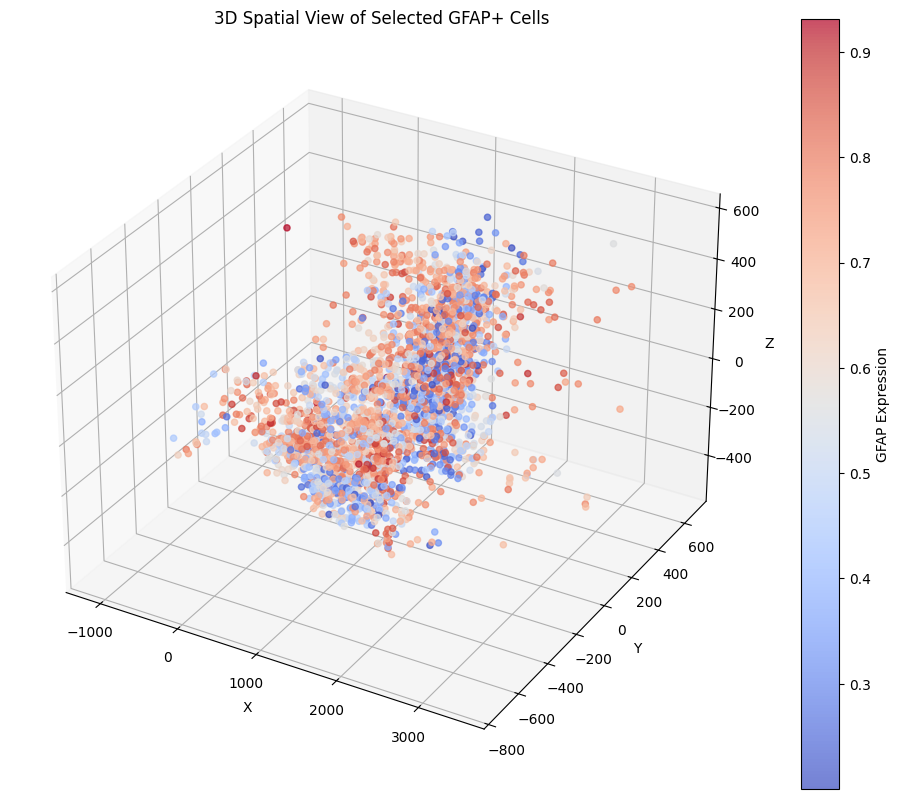

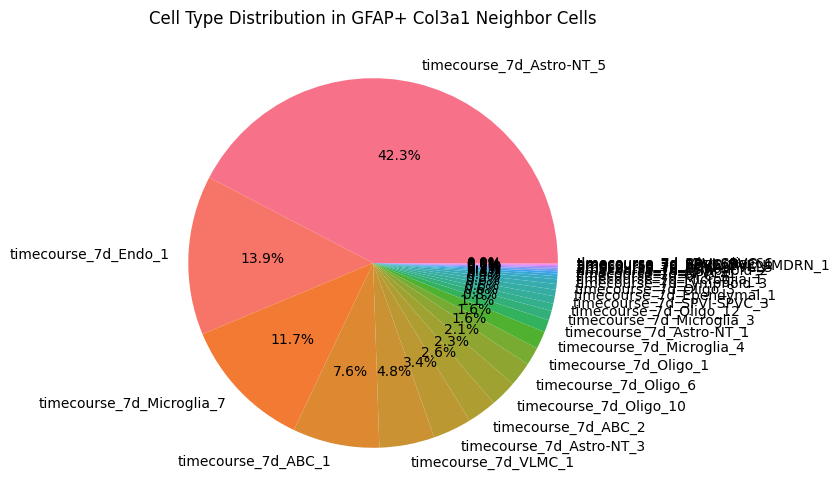

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
import scanpy as sc
import pandas as pd

# **Specify the gene names to plot**
gene1 = "Col3a1"  # expression in neighboring cells (used to set transparency)
gene2 = "Adgrg1"  # self expression (green)
gene3 = "Gfap"    # self expression (blue)

# **Set slice coordinates**
slice_x = 1250
slice_y = -500
slice_z = 0
slice_width = 75

# **Check whether the genes are present in the data**
for gene in [gene1, gene2, gene3]:
    if gene not in adata_3d.var_names:
        raise ValueError(f"{gene} is not present in the data")

# **Get gene expression data (as numpy arrays)**
gene1_expression = adata_3d[:, gene1].X.toarray().flatten()
gene2_expression = adata_3d[:, gene2].X.toarray().flatten()
gene3_expression = adata_3d[:, gene3].X.toarray().flatten()

# **Normalize (scale to the range 0-1)**
def normalize(exp):
    return (exp - exp.min()) / (exp.max() - exp.min())

gene1_expression = normalize(gene1_expression)
gene2_expression = normalize(gene2_expression)
gene3_expression = normalize(gene3_expression)

# **Get 3D coordinate information**
coords = np.vstack((adata_3d.obs["x"].values, adata_3d.obs["y"].values, adata_3d.obs["z"].values)).T

# **Find neighboring cells via nearest-neighbor search**
nbrs = NearestNeighbors(n_neighbors=5, algorithm='ball_tree').fit(coords)
distances, indices = nbrs.kneighbors(coords)

# **Compute the COL3A1 expression of neighboring cells**
neighbor_col3a1 = np.array([gene1_expression[indices[i]].mean() for i in range(len(gene1_expression))])

# **Thresholds**
col3a1_threshold = 0.2  # threshold for Col3a1-positive cells
threshold1 = 0.2  # neighbor COL3A1 expression (threshold for cells to highlight)
threshold2 = 0.2  # self ADGRG1 expression (applied only to GFAP-positive cells)
threshold3 = 0.2  # self GFAP expression

# **Show Col3a1-positive cells independently**
col3a1_cells = gene1_expression > col3a1_threshold

# **Highlight only GFAP-positive cells that also express ADGRG1**
selected_cells = (neighbor_col3a1 > threshold1)
selected_green_blue = selected_cells & (gene3_expression > threshold3) & (gene2_expression > threshold2)

# **Set colors and transparency for visualization**
colors = np.ones((len(gene1_expression), 4))
colors[:, :3] = 0.8  # light gray for all cells
colors[:, 3] = 0.05  # alpha = 0.05

# **Display Col3a1-positive cells in red**
colors[col3a1_cells, 0] = gene1_expression[col3a1_cells]
colors[col3a1_cells, 1] = 0.0
colors[col3a1_cells, 2] = 0.0
colors[col3a1_cells, 3] = 1.0

# **Display GFAP & Adgrg1 double-positive cells with color intensity scaled by expression**
colors[selected_green_blue, 0] = 0.0
colors[selected_green_blue, 1] = gene2_expression[selected_green_blue]
colors[selected_green_blue, 2] = gene3_expression[selected_green_blue]
colors[selected_green_blue, 3] = 1.0

# **scRNA-seq classification model**
h5ad_file = '/content/drive/MyDrive/scRNA_analysis/Results_0-1m/Meta_Mix_CPDB.h5ad'

# Load scRNA-seq data
adata_sc = sc.read_h5ad(h5ad_file)

# Select only cells whose batch is "timecourse_7d"
adata_sc = adata_sc[(adata_sc.obs["batch"] == "timecourse_7d_4") | (adata_sc.obs["batch"] == "timecourse_7d_9")].copy()

# Get common genes (do not modify the gene list of adata_3d)
common_genes = list(set(adata_sc.var_names) & set(adata_3d.var_names))
adata_sc = adata_sc[:, common_genes]
adata_3d_common = adata_3d[:, common_genes]  # temporary object used only for prediction

# Build the KNN classifier
sc_expression = adata_sc.X.toarray()
sc_labels = adata_sc.obs["cell_labels"].values
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(sc_expression, sc_labels)

# Classify the spatial data (do not modify the original adata_3d)
spatial_expression = adata_3d_common.X.toarray()
predicted_labels = knn.predict(spatial_expression)

# **Add predicted_cell_type to adata_3d.obs**
adata_3d.obs["predicted_cell_type"] = predicted_labels

# **Create 3D plot and cross-section views**
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(coords[selected_green_blue, 0], coords[selected_green_blue, 1], coords[selected_green_blue, 2], c=gene3_expression[selected_green_blue], cmap='coolwarm', alpha=0.7)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Spatial View of Selected GFAP+ Cells")
plt.colorbar(sc, label="GFAP Expression")
plt.show()

# **Visualize the cell-type composition of GFAP-positive cells as a pie chart**
selected_types = adata_3d.obs.loc[selected_green_blue, "predicted_cell_type"]
type_counts = selected_types.value_counts()
plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=sns.color_palette("husl", len(type_counts)))
plt.title("Cell Type Distribution in GFAP+ Col3a1 Neighbor Cells")
plt.show()

/tmp/ipykernel_3027/2554333381.py:138: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


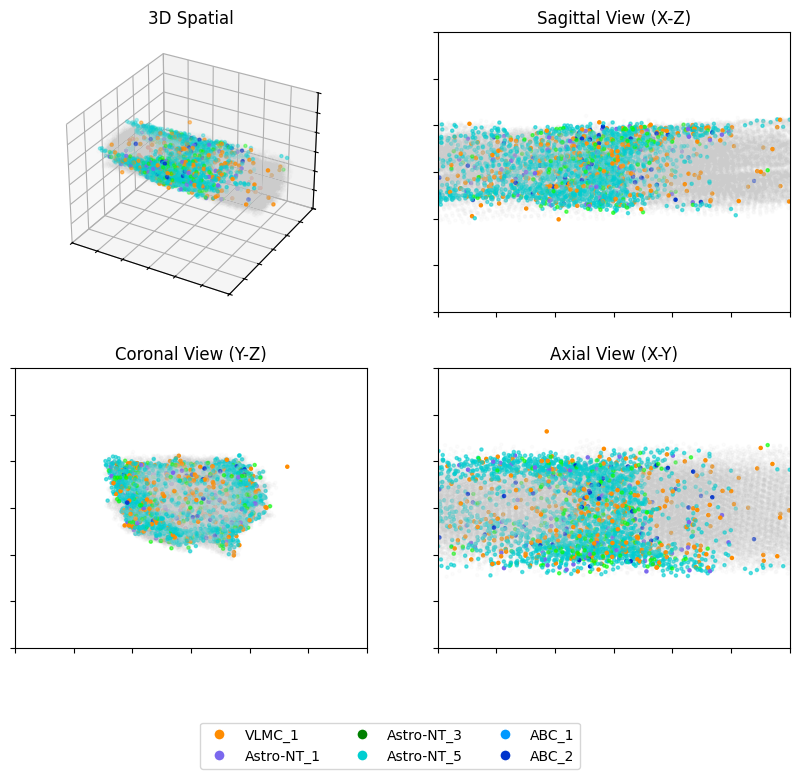

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import NearestNeighbors
import scanpy as sc
import pandas as pd

gene1 = "Col3a1"

if gene1 not in adata_3d.var_names:
    raise ValueError(f"{gene1} is not present in the data")

gene1_expression = adata_3d[:, gene1].X.toarray().flatten()

def normalize(exp):
    return (exp - exp.min()) / (exp.max() - exp.min())

gene1_expression = normalize(gene1_expression)

coords = np.vstack((
    adata_3d.obs["x"].values,
    adata_3d.obs["y"].values,
    adata_3d.obs["z"].values
)).T


x_range = [0, 3000]
y_range = [-1500, 1500]
z_range = [-1500, 1500]


nbrs = NearestNeighbors(n_neighbors=5, algorithm='ball_tree').fit(coords)
distances, indices = nbrs.kneighbors(coords)
neighbor_col3a1 = np.array([gene1_expression[indices[i]].mean() for i in range(len(gene1_expression))])


threshold1 = 0.2


vlmc1_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_VLMC_1") & (gene1_expression > threshold1)

astro_nt1_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_Astro-NT_1") & (neighbor_col3a1 > threshold1)
astro_nt3_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_Astro-NT_3") & (neighbor_col3a1 > threshold1)
astro_nt5_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_Astro-NT_5") & (neighbor_col3a1 > threshold1)
abc2_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_ABC_2") & (gene1_expression > threshold1)
abc1_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_ABC_1") & (gene1_expression > threshold1)

colors = np.ones((len(gene1_expression), 4))
colors[:, :3] = 0.8
colors[:, 3] = 0.05

# VLMC_1 → #ff8c00 (orange)
colors[vlmc1_cells] = [1.0, 0.549, 0.0, 1.0]
# Astro-NT_1 → purple
colors[astro_nt1_cells] = [0.482, 0.408, 0.933, 1.0]
# Astro-NT_3 → green
colors[astro_nt3_cells] = [0.0, 1.0, 0.0, 0.6]
# Astro-NT_5 → 00ced1
colors[astro_nt5_cells] = [0.0, 0.808, 0.820, 0.6]
# ABC_1 → #0099ff (light blue)
colors[abc2_cells] = [0.0, 0.6, 1.0, 1.0]
# ABC_2 → #0033cc (dark blue)
colors[abc2_cells] = [0.0, 0.2, 0.8, 1.0]

in_x = (coords[:, 0] >= x_range[0]) & (coords[:, 0] <= x_range[1])
in_y = (coords[:, 1] >= y_range[0]) & (coords[:, 1] <= y_range[1])
in_z = (coords[:, 2] >= z_range[0]) & (coords[:, 2] <= z_range[1])
in_box = in_x & in_y & in_z


coords_filtered = coords[in_box]
colors_filtered = colors[in_box]


fig = plt.figure(figsize=(10, 8))


ax = fig.add_subplot(221, projection='3d')
ax.scatter(coords_filtered[:, 0], coords_filtered[:, 1], coords_filtered[:, 2], c=colors_filtered, s=5)
ax.set_xlim(x_range)
ax.set_ylim(y_range)
ax.set_zlim(z_range)
ax.set_title("3D Spatial")

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])


ax_sagittal = fig.add_subplot(222)
ax_sagittal.scatter(coords_filtered[:, 0], coords_filtered[:, 2], c=colors_filtered[:, :3], alpha=colors_filtered[:, 3], s=5)
ax_sagittal.set_xlim(x_range)
ax_sagittal.set_ylim(z_range)
ax_sagittal.set_title("Sagittal View (X-Z)")
ax_sagittal.set_xlabel("")
ax_sagittal.set_ylabel("")
ax_sagittal.set_xticklabels([])
ax_sagittal.set_yticklabels([])


ax_coronal = fig.add_subplot(223)
ax_coronal.scatter(coords_filtered[:, 1], coords_filtered[:, 2], c=colors_filtered[:, :3], alpha=colors_filtered[:, 3], s=5)
ax_coronal.set_xlim(y_range)
ax_coronal.set_ylim(z_range)
ax_coronal.set_title("Coronal View (Y-Z)")
ax_coronal.set_xlabel("")
ax_coronal.set_ylabel("")
ax_coronal.set_xticklabels([])
ax_coronal.set_yticklabels([])


ax_axial = fig.add_subplot(224)
ax_axial.scatter(coords_filtered[:, 0], coords_filtered[:, 1], c=colors_filtered[:, :3], alpha=colors_filtered[:, 3], s=5)
ax_axial.set_xlim(x_range)
ax_axial.set_ylim(y_range)
ax_axial.set_title("Axial View (X-Y)")
ax_axial.set_xlabel("")
ax_axial.set_ylabel("")
ax_axial.set_xticklabels([])
ax_axial.set_yticklabels([])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff8c00', markersize=8, label="VLMC_1"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#7b68ee', markersize=8, label="Astro-NT_1"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label="Astro-NT_3"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#00ced1', markersize=8, label="Astro-NT_5"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#0099ff', markersize=8, label="ABC_1"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#0033cc', markersize=8, label="ABC_2")
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
fig.savefig("Spatial_filtered.tiff", format="tiff", dpi=300, transparent=True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import NearestNeighbors
import scanpy as sc
import pandas as pd

gene1 = "Col3a1"

if gene1 not in adata_3d.var_names:
    raise ValueError(f"{gene1} is not present in the data")

gene1_expression = adata_3d[:, gene1].X.toarray().flatten()

def normalize(exp):
    return (exp - exp.min()) / (exp.max() - exp.min())

gene1_expression = normalize(gene1_expression)

coords = np.vstack((
    adata_3d.obs["x"].values,
    adata_3d.obs["y"].values,
    adata_3d.obs["z"].values
)).T


x_range = [0, 3000]
y_range = [-1500, 1500]
z_range = [-1500, 1500]


nbrs = NearestNeighbors(n_neighbors=5, algorithm='ball_tree').fit(coords)
distances, indices = nbrs.kneighbors(coords)
neighbor_col3a1 = np.array([gene1_expression[indices[i]].mean() for i in range(len(gene1_expression))])


threshold1 = 0.2


vlmc1_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_VLMC_1") & (gene1_expression > threshold1)
vlmc2_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_VLMC_2") & (gene1_expression > threshold1)
astro_nt1_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_Astro-NT_3") & (neighbor_col3a1 > threshold1)
abc1_cells = (adata_3d.obs["predicted_cell_type"] == "timecourse_7d_ABC_1") & (gene1_expression > threshold1)


colors = np.ones((len(gene1_expression), 4))
colors[:, :3] = 0.8
colors[:, 3] = 0.05

# VLMC_1 → cyan
colors[vlmc1_cells] = [0.0, 0.6, 1.0, 1.0]

# VLMC_`2 → magenta
colors[vlmc2_cells] = [1.0, 0.0, 1.0, 1.0]

# Astro-NT_1 → green
colors[astro_nt1_cells] = [0.0, 1.0, 0.0, 0.6]

# ABC_1 → orange
colors[abc_1_cells] = [1.0, 0.5, 0.0, 1.0]

in_x = (coords[:, 0] >= x_range[0]) & (coords[:, 0] <= x_range[1])
in_y = (coords[:, 1] >= y_range[0]) & (coords[:, 1] <= y_range[1])
in_z = (coords[:, 2] >= z_range[0]) & (coords[:, 2] <= z_range[1])
in_box = in_x & in_y & in_z


coords_filtered = coords[in_box]
colors_filtered = colors[in_box]


fig = plt.figure(figsize=(10, 8))


ax = fig.add_subplot(221, projection='3d')
ax.scatter(coords_filtered[:, 0], coords_filtered[:, 1], coords_filtered[:, 2], c=colors_filtered, s=5)
ax.set_xlim(x_range)
ax.set_ylim(y_range)
ax.set_zlim(z_range)
ax.set_title("3D Spatial: VLMC_1, VLMC_2, Astro-NT_3, ABC_1")

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])


ax_sagittal = fig.add_subplot(222)
ax_sagittal.scatter(coords_filtered[:, 0], coords_filtered[:, 2], c=colors_filtered[:, :3], alpha=colors_filtered[:, 3], s=5)
ax_sagittal.set_xlim(x_range)
ax_sagittal.set_ylim(z_range)
ax_sagittal.set_title("Sagittal View (X-Z)")
ax_sagittal.set_xlabel("")
ax_sagittal.set_ylabel("")
ax_sagittal.set_xticklabels([])
ax_sagittal.set_yticklabels([])


ax_coronal = fig.add_subplot(223)
ax_coronal.scatter(coords_filtered[:, 1], coords_filtered[:, 2], c=colors_filtered[:, :3], alpha=colors_filtered[:, 3], s=5)
ax_coronal.set_xlim(y_range)
ax_coronal.set_ylim(z_range)
ax_coronal.set_title("Coronal View (Y-Z)")
ax_coronal.set_xlabel("")
ax_coronal.set_ylabel("")
ax_coronal.set_xticklabels([])
ax_coronal.set_yticklabels([])


ax_axial = fig.add_subplot(224)
ax_axial.scatter(coords_filtered[:, 0], coords_filtered[:, 1], c=colors_filtered[:, :3], alpha=colors_filtered[:, 3], s=5)
ax_axial.set_xlim(x_range)
ax_axial.set_ylim(y_range)
ax_axial.set_title("Axial View (X-Y)")
ax_axial.set_xlabel("")
ax_axial.set_ylabel("")
ax_axial.set_xticklabels([])
ax_axial.set_yticklabels([])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan', markersize=8, label="VLMC_1"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='magenta', markersize=8, label="VLMC_2"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label="Astro-NT_3"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label="ABC_1")
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
fig.savefig("Spatial_filtered.tiff", format="tiff", dpi=300, transparent=True)
plt.show()

NameError: name 'abc_1_cells' is not defined